In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [8]:
def load_csv(path):
    return pd.read_csv(path, encoding="latin1")

customers = load_csv("customers.csv")
orders = load_csv("orders.csv")
order_details = load_csv("order_details.csv")
products = load_csv("products.csv")
categories = load_csv("categories.csv")
employees = load_csv("employees.csv")

In [9]:
df = order_details.merge(orders, on="orderID")
df = df.merge(products, on="productID")
df = df.merge(categories, on="categoryID")
df = df.merge(customers, on="customerID")
df = df.merge(employees, on="employeeID")

In [10]:
df["Revenue"] = df["unitPrice_x"] * df["quantity"] * (1 - df["discount"])
df["orderDate"] = pd.to_datetime(df["orderDate"])

In [11]:
sales_per_product = df.groupby("productName")["Revenue"].sum().sort_values(ascending=False)
sales_per_category = df.groupby("categoryName")["Revenue"].sum().sort_values(ascending=False)

print("\n--- Total Sales per Product ---")
print(sales_per_product.head())

print("\n--- Total Sales per Category ---")
print(sales_per_category)


--- Total Sales per Product ---
productName
Côte de Blaye              141396.735
Thüringer Rostbratwurst     80368.672
Raclette Courdavault        71155.700
Tarte au sucre              47234.970
Camembert Pierrot           46825.480
Name: Revenue, dtype: float64

--- Total Sales per Category ---
categoryName
Beverages           267868.1800
Dairy Products      234507.2850
Confections         167357.2250
Meat & Poultry      163022.3595
Seafood             131261.7375
Condiments          106047.0850
Produce              99984.5800
Grains & Cereals     95744.5875
Name: Revenue, dtype: float64


In [12]:
top_customers = df.groupby("companyName")["Revenue"].sum().sort_values(ascending=False).head(5)

print("\n--- Top 5 Customers ---")
print(top_customers)


--- Top 5 Customers ---
companyName
QUICK-Stop                      110277.3050
Ernst Handel                    104874.9785
Save-a-lot Markets              104361.9500
Rattlesnake Canyon Grocery       51097.8005
Hungry Owl All-Night Grocers     49979.9050
Name: Revenue, dtype: float64


In [13]:
orders_per_country = df.groupby("country_x")["orderID"].nunique().sort_values(ascending=False)

print("\n--- Orders per Country ---")
print(orders_per_country)


--- Orders per Country ---
country_x
Germany        122
USA            122
Brazil          83
France          77
UK              56
Venezuela       46
Austria         40
Sweden          37
Canada          30
Mexico          28
Italy           28
Spain           23
Finland         22
Ireland         19
Belgium         19
Switzerland     18
Denmark         18
Argentina       16
Portugal        13
Poland           7
Norway           6
Name: orderID, dtype: int64


In [14]:
df["Month"] = df["orderDate"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Revenue"].sum()

print("\n--- Monthly Sales Trend ---")
print(monthly_sales)


--- Monthly Sales Trend ---
Month
2013-07     27861.8950
2013-08     25485.2750
2013-09     26381.4000
2013-10     37515.7250
2013-11     45600.0450
2013-12     45239.6300
2014-01     61258.0700
2014-02     38483.6350
2014-03     38547.2200
2014-04     53032.9525
2014-05     53781.2900
2014-06     36362.8025
2014-07     51020.8575
2014-08     47287.6700
2014-09     55629.2425
2014-10     66749.2260
2014-11     43533.8090
2014-12     71398.4285
2015-01     94222.1105
2015-02     99415.2875
2015-03    104854.1550
2015-04    123798.6825
2015-05     18333.6305
Freq: M, Name: Revenue, dtype: float64


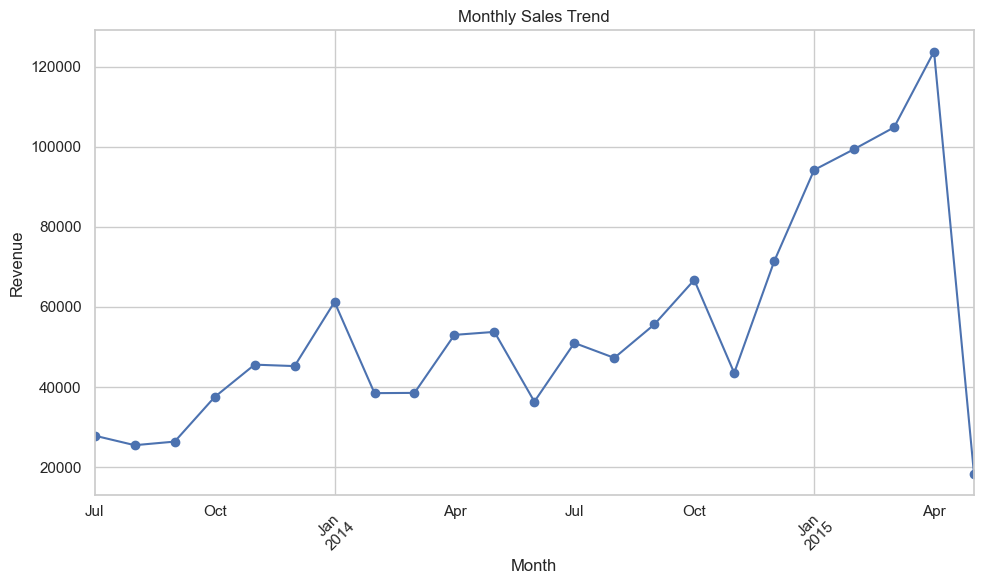

In [15]:
plt.figure()
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
order_totals = df.groupby(["orderID", "employeeID"])["Revenue"].sum().reset_index()
avg_order_value = order_totals.groupby("employeeID")["Revenue"].mean()

print("\n--- Avg Order Value per Employee ---")
print(avg_order_value)


--- Avg Order Value per Employee ---
employeeID
1    1561.850443
2    1734.768281
3    1596.951520
4    1492.890038
5    1637.911488
6    1103.181037
7    1730.114375
8    1219.829591
9    1797.862012
Name: Revenue, dtype: float64


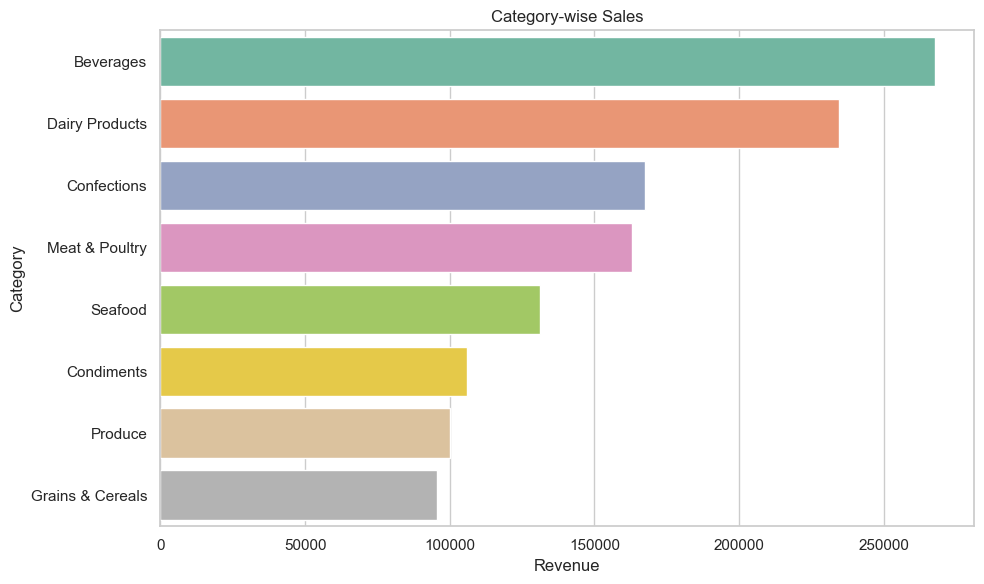

In [20]:
plt.figure()

sns.barplot(
    x=sales_per_category.values,
    y=sales_per_category.index,
    hue=sales_per_category.index,
    palette="Set2",
    legend=False
)

plt.title("Category-wise Sales")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

C:\Users\Arunangshu Dasgupta\AppData\Local\Temp\ipykernel_39588\3422490959.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


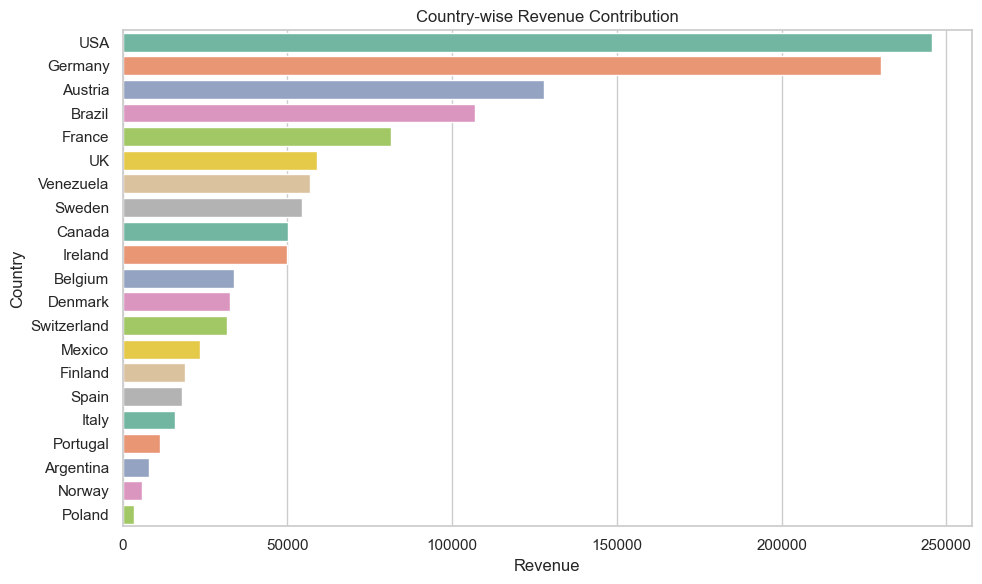

In [ ]:
country_revenue = df.groupby("country_x")["Revenue"].sum().sort_values(ascending=False)

plt.figure()

sns.barplot(
    x=country_revenue.values,
    y=country_revenue.index,
    palette="Set2" 
)

plt.title("Country-wise Revenue Contribution")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [19]:
print("\n--- BUSINESS INSIGHTS ---")

print("""
1. A small number of customers contribute a large portion of total revenue,
   indicating strong customer concentration and importance of retention.

2. Certain categories dominate sales, suggesting that focusing marketing and
   inventory on high-performing categories can maximize revenue.
""")


--- BUSINESS INSIGHTS ---

1. A small number of customers contribute a large portion of total revenue,
   indicating strong customer concentration and importance of retention.

2. Certain categories dominate sales, suggesting that focusing marketing and
   inventory on high-performing categories can maximize revenue.

